Dataset Link: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

This dataset is a curated combination of the following publicly available datasets:
- figshare brain MRI dataset
- SARTAJ dataset
- Br35H dataset

The dataset contains 7,200 human brain MRI images categorized into four classes:
- Glioma
- Meningioma
- Pituitary tumor
- No tumor



### Requirements:
- Apply at least 2 filtering techniques
  - Gaussian Filter
  - Median Filter

- Compare results visually and numerically

In [15]:
from pathlib import Path

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [9]:
import cv2
import os

# load data using folder traversal
# resize data and convert to grayscale to reduce noise and computational load
def load_data(base_path, img_size=(256,256)):
    images = []
    labels = []
    
    classes = os.listdir(base_path)
    
    for label in classes:
        class_path = os.path.join(base_path, label)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue # skip if image is not loaded properly / corrupted
            img = cv2.resize(img, img_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            images.append(img)
            labels.append(label)
            
    return images, labels

In [ ]:
X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

In [25]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))
print(X_train[0].shape)

5600 5600
1600 1600
(256, 256)


In [26]:
from collections import Counter

print(Counter(y_train))
print(Counter(y_test))

Counter({'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400})
Counter({'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400})


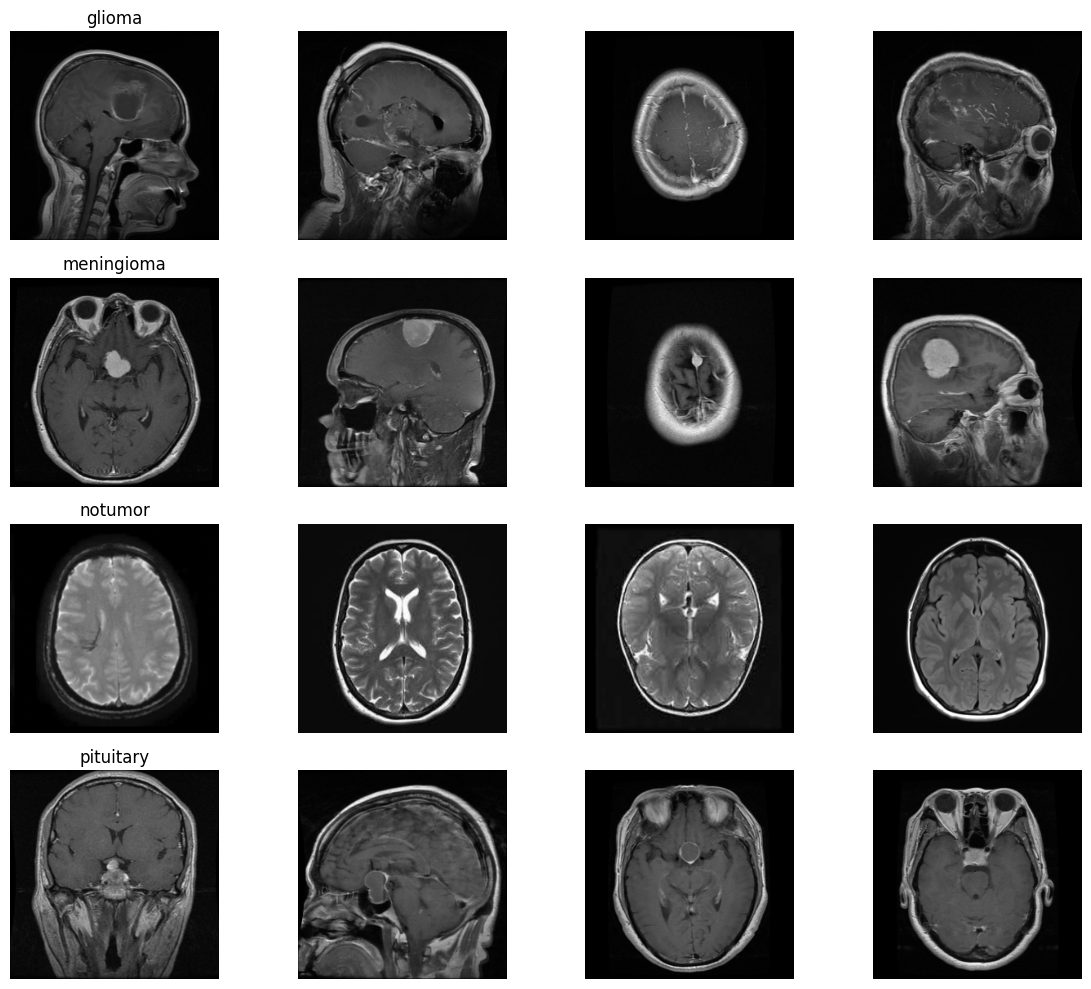

In [30]:
import matplotlib.pyplot as plt
import random
random.seed(42)

classes = sorted(list(set(y_train)))

fig, axes = plt.subplots(len(classes), 4, figsize=(12, 10))

for row, cls in enumerate(classes):
    # get indices for this class
    idxs = [i for i, label in enumerate(y_train) if label == cls]
    random.shuffle(idxs)
    for col in range(4):
        img = X_train[idxs[col]]

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(cls)

plt.tight_layout()
plt.show()

In [ ]:
# Implement filters
# Apply both filters: Gaussian, Median
# Visual comparison
# Numerical evaluation with PSNR and SSIM

# Chosen filter → (Gaussian / Median / Both)
# Reason → explanation based on results